In [1]:
import fatesens as fs
import scanpy as sc
import numpy as np
import pandas as pd

/Users/ps-lab-noman/Research/FateSens/.venv/lib/python3.12/site-packages/tqdm_joblib/__init__.py:4: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [ ]:
day_t0 = [2, 4]
day_t1 = [4, 6]
day_column_name = "time_info"
n_neighbor_for_jacobian = 20

In [3]:
adata = sc.read(
    "../data/adata.h5ad"
)
adata = sc.pp.subsample(adata, fraction=0.2, copy=True)
adata

AnnData object with n_obs × n_vars = 6956 × 23420
    obs: 'Library', 'Cell barcode', 'time_info', 'Starting population', 'state_info', 'Well', 'SPRING-x', 'SPRING-y', 'Neutrophil_pDC_raw_score', 'Neutrophil_pDC_smoothed_score', 'Neutrophil_pDC_fate_class', 'Neutrophil_Monocyte_raw_score', 'Neutrophil_Monocyte_smoothed_score', 'Neutrophil_Monocyte_fate_class', 'is_boundary_between_clonal_sisters_Neutrophil_Monocyte', 'is_boundary_between_clonal_sisters_Neutrophil_pDC'
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand'
    uns: 'data_des', 'neighbors', 'state_info_colors'
    obsm: 'X_clone', 'X_emb'
    layers: 'ambiguous', 'matrix', 'spliced', 'unspliced'
    obsp: 'connectivities', 'distances'

### Preprocessing

In [4]:
adata = fs.pp.get_highly_variable_genes_subset(adata)

### Flow map estimation

In [5]:
tmap = fs.flow_map.get_transport_map(adata, days=[2, 4, 6],)

In [7]:
x_0 = fs.flow_map.get_day_t0_expression(adata, days_t0=day_t0,)
x_t = fs.flow_map.get_flow_map(adata, tmap, days_t0=day_t0,)

### Estimate Jacobian

In [10]:
jacobians = fs.jacobian_matrix.estimate_jacobian_of_flow_map(
    adata,
    x_0,
    x_t,
    days_t0=day_t0,
    day_column_name=day_column_name,
    n_neighbors=n_neighbor_for_jacobian,
    beta=10
)

Function: get_jacobian, Workers: 5
Running in parallel with 5/10 jobs


Processing:   0%|          | 0/2944 [00:00<?, ?it/s]

### Sensitivity to function

In [ ]:
mono_markers = fs.tl.get_marker_gene_for_fate(
    adata,
    fate="Monocyte"
)
neutro_markers = fs.tl.get_marker_gene_for_fate(
    adata,
    fate="Neutrophil"
)
monocyte_filter_matrix = fs.tl.get_filter_matrix(adata, mono_markers)
neutrophil_filter_matrix = fs.tl.get_filter_matrix(adata, neutro_markers)

In [ ]:
sensitivity_mono = fs.jacobian_matrix.estimate_sensitivity(
    adata=adata,
    all_jacobians=jacobians,
    x_t=x_t,
    positives=[monocyte_filter_matrix],
    negatives=[neutrophil_filter_matrix],
    days_t0=day_t0,
)

df = fs.tl.calculate_sensitivity_scores_stats(
    adata,
    sensitivities=sensitivity_mono,
    days_t0=day_t0,
)

Function: estimate, Workers: 5
Running in parallel with 5/10 jobs


Processing:   0%|          | 0/2944 [00:00<?, ?it/s]

### Regulatory gene estimation

Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


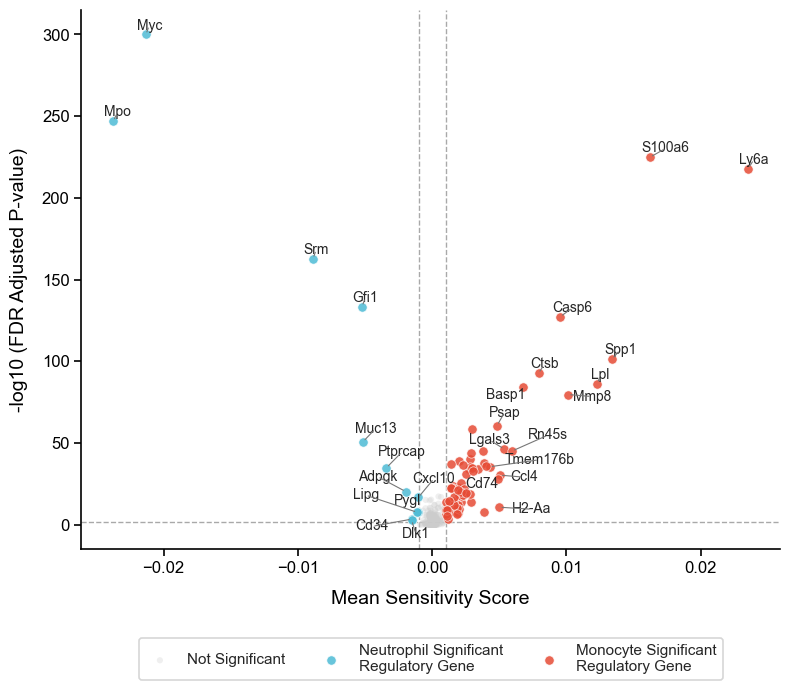

In [13]:
fs.pl.plot_sensitivity_volcano(
    df,
    score_thresh=0.001,
)

In [14]:
sensitivity_mono_only = fs.jacobian_matrix.estimate_sensitivity(
    adata=adata,
    all_jacobians=jacobians,
    x_t=x_t,
    positives=[monocyte_filter_matrix],
    negatives=[],
    days_t0=day_t0,
)

sensitivity_neutro_only = fs.jacobian_matrix.estimate_sensitivity(
    adata=adata,
    all_jacobians=jacobians,
    x_t=x_t,
    positives=[neutrophil_filter_matrix],
    negatives=[],
    days_t0=day_t0,
)

mean_sensitivity_mono_only = fs.tl.calculate_mean_sensitivity(
    adata,
    sensitivities=sensitivity_mono_only,
    days_t0=day_t0,
)
mean_sensitivity_neutro_only = fs.tl.calculate_mean_sensitivity(
    adata,
    sensitivities=sensitivity_neutro_only,
    days_t0=day_t0,
)

Function: estimate, Workers: 5
Running in parallel with 5/10 jobs


Processing:   0%|          | 0/2944 [00:00<?, ?it/s]

Function: estimate, Workers: 5
Running in parallel with 5/10 jobs


Processing:   0%|          | 0/2944 [00:00<?, ?it/s]

/Users/ps-lab-noman/Research/FateSens/.venv/lib/python3.12/site-packages/textalloc/__init__.py:495: UserWarning: Usage of allocate_text will be replaced with allocate in future releases, removing the need for the fig argument
  warnings.warn(


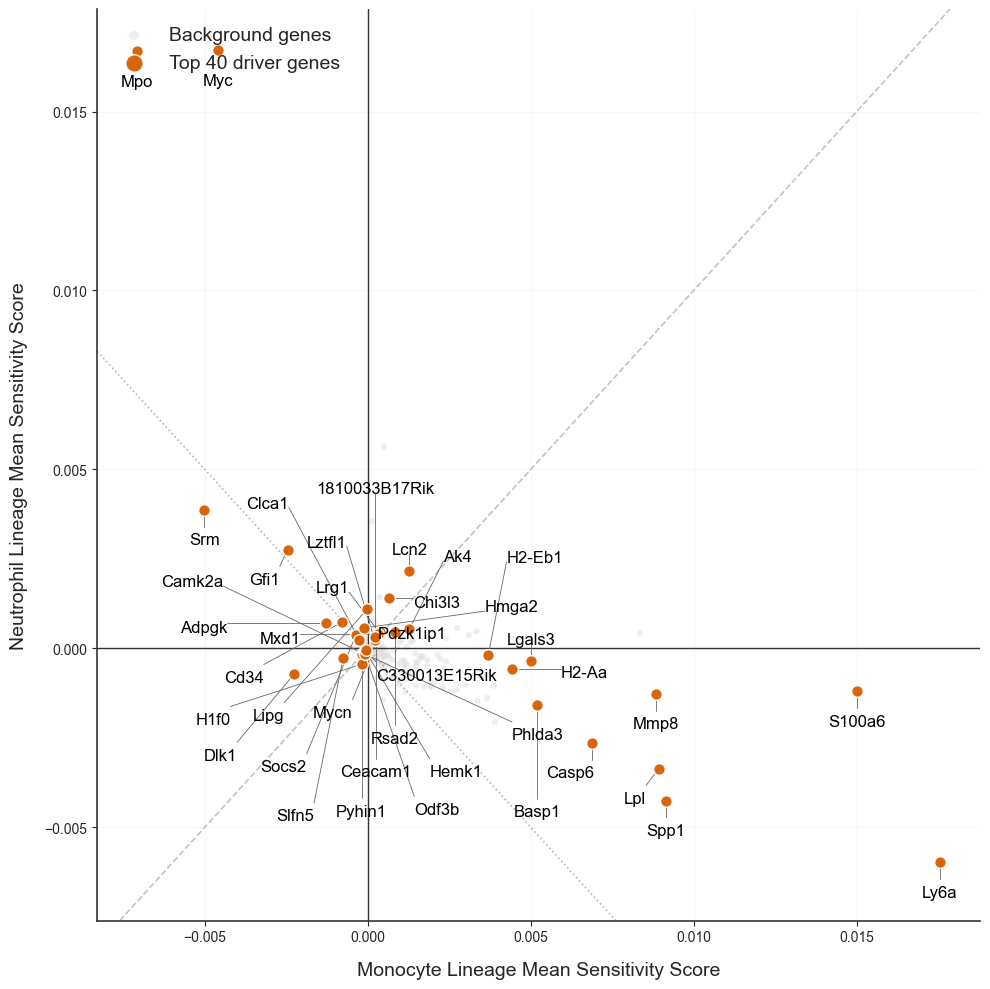

In [15]:
fs.pl.plot_sensitivity_comparison(
    adata,
    mean_sensitivity_mono_only,
    mean_sensitivity_neutro_only,
    fate1_name="Monocyte",
    fate2_name="Neutrophil"
)

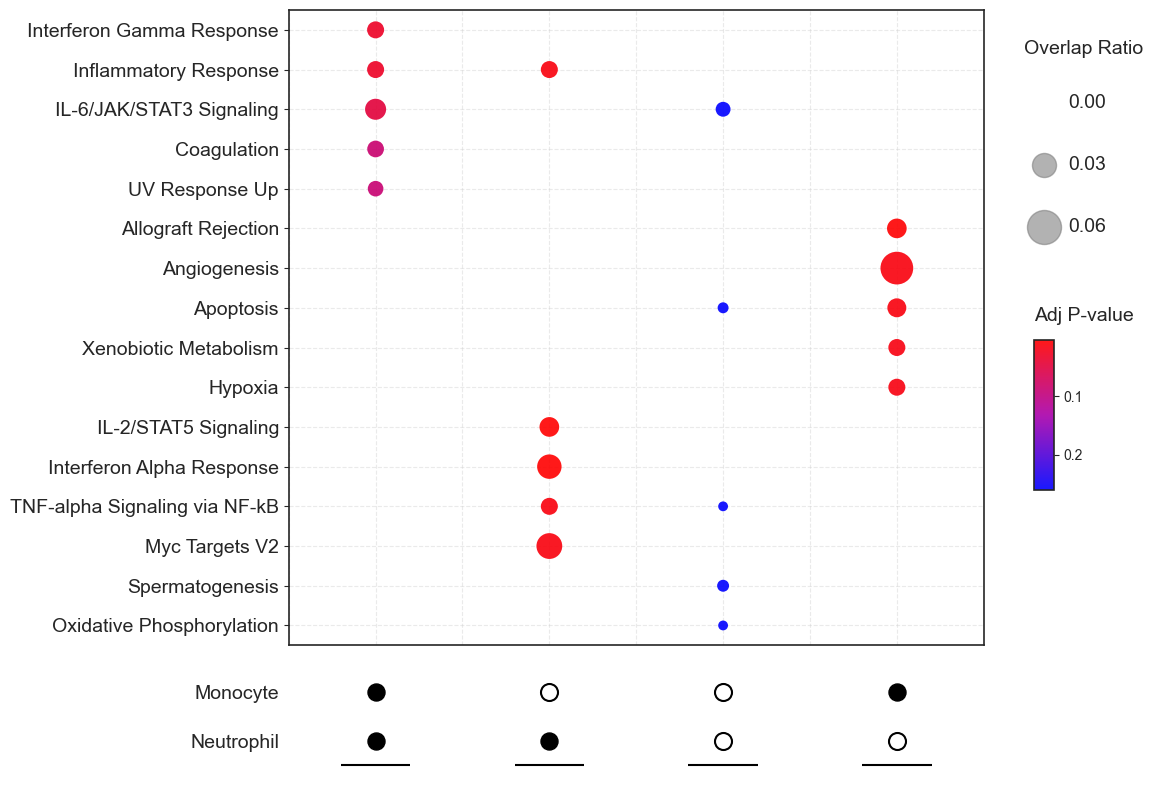

In [17]:
fs.pl.plot_enrichment_matrix_dotplot(
    adata,
    mean_sensitivities_fate1=mean_sensitivity_mono_only,
    mean_sensitivities_fate2=mean_sensitivity_neutro_only,
    top_n=30,
)

In [29]:
adata = fs.tl.get_2_type_of_clonal_trajectory(adata, N=3, n_neighbors=15)
gt_genes = fs.tl.get_ground_truth_regulatory_degs(adata, root_state="Undifferentiated", terminal_fate="Monocyte-like",)

raw median: 0.0
smoothed median: 0.0


In [30]:
df_wot_tf = fs.tl.compute_fate_trajectories_and_diff_exp_wot(adata, days_t0=day_t0,)
wot_tfs_genes = fs.tl.filter_and_select_tf_wot(df_wot_tf)

/Users/ps-lab-noman/Research/FateSens/.venv/lib/python3.12/site-packages/statsmodels/stats/multitest.py:186: RuntimeWarning: divide by zero encountered in log1p
  np.log1p(-pvals))
/Users/ps-lab-noman/Research/FateSens/.venv/lib/python3.12/site-packages/statsmodels/stats/multitest.py:186: RuntimeWarning: divide by zero encountered in log1p
  np.log1p(-pvals))
/Users/ps-lab-noman/Research/FateSens/.venv/lib/python3.12/site-packages/statsmodels/stats/multitest.py:186: RuntimeWarning: divide by zero encountered in log1p
  np.log1p(-pvals))
/Users/ps-lab-noman/Research/FateSens/.venv/lib/python3.12/site-packages/statsmodels/stats/multitest.py:186: RuntimeWarning: divide by zero encountered in log1p
  np.log1p(-pvals))
/Users/ps-lab-noman/Research/FateSens/.venv/lib/python3.12/site-packages/statsmodels/stats/multitest.py:186: RuntimeWarning: divide by zero encountered in log1p
  np.log1p(-pvals))
/Users/ps-lab-noman/Research/FateSens/.venv/lib/python3.12/site-packages/statsmodels/stats/mult

In [31]:
fs_mean_sensitivity = fs.tl.calculate_mean_sensitivity(
            adata,
            sensitivity_mono,
            days_t0=[2, 4]
)

df_fs_tf = pd.DataFrame(
    {
        "gene": adata.var_names,
        "score": np.atleast_1d(np.squeeze(fs_mean_sensitivity)).tolist(),
    }
).sort_values("score", ascending=False)

fs_tfs_genes = df_fs_tf["gene"][df_fs_tf["score"] > 0].values

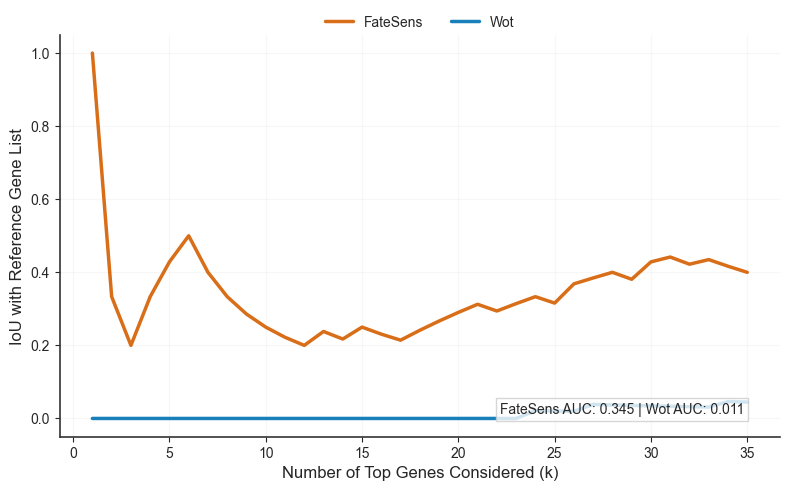

In [32]:
fs.pl.plot_iou_concordance(
    gene_lists=[fs_tfs_genes, gt_genes, wot_tfs_genes],
    method_names=["FateSens", "Wot"],
    reference_method_idx=1
)